# Segmentación de Clientes Mayoristas con Aprendizaje No Supervisado

**Trabajo Práctico Final — Módulo: Aprendizaje No Supervisado**

**Autores:** Federico Moran · Juan Barboza

**Dataset:** [Wholesale Customers — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/292/wholesale%2Bcustomers)

---

## Contenido

1. Introducción y objetivos
2. Carga del dataset
3. Análisis exploratorio de datos (EDA)
4. Preprocesamiento
5. Baseline de referencia: K-Means
6. Agglomerative Clustering
7. Gaussian Mixture Models
8. Deep Embedded Clustering (DEC)
9. Evaluación y comparación de métodos
10. Visualización con t-SNE
11. Discusión y conclusiones
12. Referencias

## 1. Introducción y objetivos

### 1.1 Descripción del problema

La segmentación de clientes constituye un problema central en la analítica de negocios: permite adaptar políticas comerciales, logísticas y de precios a grupos de clientes con comportamientos homogéneos. En el caso de un distribuidor mayorista, la cartera de clientes es intrínsecamente heterogénea: coexisten hoteles, restaurantes y cafeterías (canal *Horeca*) con comercios minoristas (canal *Retail*), cada uno con patrones de compra potencialmente distintos según la categoría de producto.

Dado que no se dispone de una variable objetivo que indique a qué segmento pertenece cada cliente, el problema se aborda mediante **aprendizaje no supervisado**: se busca descubrir la estructura de grupos latente en los datos de gasto anual y caracterizarla en términos interpretables para el negocio.

### 1.2 Dataset seleccionado y justificación

Se utiliza el dataset **Wholesale Customers** del repositorio UCI Machine Learning Repository (Cardoso, 2013), que registra el gasto anual, expresado en unidades monetarias (u.m.), de **440 clientes** de un distribuidor mayorista de Portugal en **seis categorías de producto**: productos frescos (`Fresh`), lácteos (`Milk`), almacén (`Grocery`), congelados (`Frozen`), detergentes y papel (`Detergents_Paper`) y delicatessen (`Delicassen`). Adicionalmente incluye dos variables categóricas: el canal de venta (`Channel`: Horeca o Retail) y la región (`Region`: Lisboa, Oporto u otra).

La elección del dataset se justifica por los siguientes motivos:

- **Disponibilidad pública y trazabilidad:** el dataset está publicado en UCI con DOI (10.24432/C5030X) y se descarga de forma automática desde este notebook, lo que garantiza la reproducibilidad del análisis.
- **Adecuación al problema:** las seis variables de gasto son continuas y estrictamente positivas, apropiadas para algoritmos de agrupamiento basados en distancias y en densidades.
- **Posibilidad de validación externa:** las variables `Channel` y `Region` no se utilizan como atributos de agrupamiento, sino que se reservan como *pseudo-etiquetas* para evaluar externamente los clusters obtenidos.
- **Interpretabilidad:** el dominio (compras mayoristas) permite traducir los resultados a conclusiones de negocio concretas.

### 1.3 Objetivos

**Objetivo general:** identificar y caracterizar segmentos de clientes mayoristas a partir de su patrón de gasto anual, aplicando y comparando técnicas de aprendizaje no supervisado.

**Objetivos específicos:**

1. Realizar un análisis exploratorio que evalúe la calidad de los datos, describa las variables y detecte valores atípicos.
2. Definir y justificar un esquema de preprocesamiento adecuado a las características de los datos.
3. Aplicar tres algoritmos de agrupamiento — *Agglomerative Clustering*, *Gaussian Mixture Models* y *Deep Embedded Clustering* (DEC) — con optimización justificada de hiperparámetros, utilizando K-Means únicamente como referencia (baseline).
4. Evaluar los resultados con métricas internas (Silhouette, Davies-Bouldin, Calinski-Harabasz) y externas (ARI, NMI respecto de `Channel`).
5. Visualizar la estructura de grupos mediante t-SNE e interpretar críticamente los resultados.

## 2. Carga del dataset

### 2.1 Librerías y configuración global

En la siguiente celda se importan las librerías utilizadas a lo largo del trabajo y se fija la configuración global del análisis:

- **`numpy` y `pandas`** para la manipulación numérica y tabular de los datos.
- **`matplotlib` y `seaborn`** para las visualizaciones.
- **`requests`, `zipfile` e `io`** para descargar y descomprimir el dataset directamente desde la URL pública de UCI, sin depender de archivos locales.
- **`pathlib`** para gestionar el directorio `figures/`, donde se exportan las figuras que luego se reutilizan en el informe y la presentación.

Se fija una **semilla aleatoria global** (`RANDOM_STATE = 42`) que se reutilizará en todos los algoritmos estocásticos para garantizar la reproducibilidad de los resultados. Como paleta de colores se adopta `colorblind` de seaborn (Wong, 2011), segura para personas con daltonismo y de uso extendido en publicaciones científicas; además, se asigna un color fijo a cada canal de venta (Horeca y Retail) que se mantiene constante en todas las figuras del trabajo para facilitar su lectura comparada.

In [1]:
import io
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12

PALETA = sns.color_palette("colorblind")
COLOR_CANAL = {"Horeca": PALETA[0], "Retail": PALETA[1]}

# Directorio de figuras: <raíz del repo>/figures, tanto si el notebook se
# ejecuta desde notebooks/ como desde la raíz (p. ej. en Google Colab).
FIG_DIR = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def guardar_figura(fig, nombre):
    """Exporta la figura a figures/<nombre>.png para el informe y la presentación."""
    fig.savefig(FIG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")

### 2.2 Descarga y lectura de los datos

El dataset se distribuye desde UCI como un archivo ZIP que contiene un único CSV. La celda siguiente realiza el proceso completo en memoria:

1. Descarga el ZIP desde la URL pública mediante `requests`, con un tiempo máximo de espera de 60 segundos y verificación explícita del código de estado HTTP (`raise_for_status`), de modo que un fallo de red produzca un error claro en lugar de datos corruptos.
2. Descomprime el contenido en memoria (`io.BytesIO` + `zipfile`), sin escribir archivos intermedios en disco, lo que hace al notebook autocontenido y ejecutable sin pasos previos tanto en un entorno local como en Google Colab.
3. Localiza el CSV dentro del ZIP y lo carga en un `DataFrame` de pandas.

In [2]:
DATASET_URL = "https://archive.ics.uci.edu/static/public/292/wholesale+customers.zip"

respuesta = requests.get(DATASET_URL, timeout=60)
respuesta.raise_for_status()

with zipfile.ZipFile(io.BytesIO(respuesta.content)) as zf:
    nombre_csv = [n for n in zf.namelist() if n.lower().endswith(".csv")][0]
    with zf.open(nombre_csv) as f:
        df = pd.read_csv(f)

print(f"Archivo extraído: {nombre_csv}")
print(f"Dimensiones: {df.shape[0]} observaciones × {df.shape[1]} variables")

Archivo extraído: Wholesale customers data.csv
Dimensiones: 440 observaciones × 8 variables


### 2.3 Estructura general

Se inspecciona la estructura del `DataFrame` para verificar que la carga fue correcta: cantidad de observaciones y variables, tipos de dato de cada columna y primeras filas. Según la documentación de UCI, el dataset debe contener 440 observaciones y 8 variables, todas de tipo entero.

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 3. Análisis exploratorio de datos (EDA)

### 3.1 Calidad de los datos

Antes de cualquier análisis estadístico se evalúa la calidad del dataset, dado que condiciona las decisiones de preprocesamiento. La celda siguiente construye un resumen por variable con: tipo de dato, cantidad de valores nulos, cantidad de valores únicos y rango observado (mínimo y máximo). Adicionalmente se contabilizan las filas duplicadas.

La verificación del rango es relevante en este dominio: al tratarse de gastos anuales, un valor negativo sería inconsistente y un valor nulo o cero indicaría ausencia de actividad en esa categoría.

In [4]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "valores_únicos": df.nunique(),
    "mínimo": df.min(),
    "máximo": df.max(),
})

print(f"Filas duplicadas: {df.duplicated().sum()}")
resumen_calidad

Filas duplicadas: 0


,tipo,nulos,valores_únicos,mínimo,máximo
Channel,int64,0,2,1,2
Region,int64,0,3,1,3
Fresh,int64,0,433,3,112151
Milk,int64,0,421,55,73498
Grocery,int64,0,430,3,92780
Frozen,int64,0,426,25,60869
Detergents_Paper,int64,0,417,3,40827
Delicassen,int64,0,403,3,47943


**Interpretación.** El dataset está completo: no presenta valores nulos ni filas duplicadas, por lo que **no se requiere imputación**. Todas las variables son enteras y los mínimos de las seis variables de gasto son estrictamente positivos (entre 3 y 55 u.m.), sin valores negativos ni ceros. Cabe señalar que algunos mínimos son extremadamente bajos para un gasto anual (3 u.m.), lo que sugiere clientes con actividad casi nula en ciertas categorías; se trata de valores válidos, no de errores de registro.

### 3.2 Variables categóricas: canal y región

Las variables `Channel` y `Region` están codificadas numéricamente. Según la documentación de UCI: `Channel` toma el valor 1 para el canal *Horeca* (hoteles, restaurantes y cafeterías) y 2 para *Retail* (comercio minorista); `Region` toma los valores 1 (Lisboa), 2 (Oporto) y 3 (otra región).

En la celda siguiente se crean dos columnas auxiliares con las etiquetas legibles (`Canal` y `Región`), que se utilizarán exclusivamente para las visualizaciones y la evaluación externa — **no como atributos de agrupamiento** —, y se calculan las distribuciones de frecuencia absolutas y relativas de ambas variables, junto con su tabla de contingencia.

In [5]:
VARS_GASTO = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

df["Canal"] = df["Channel"].map({1: "Horeca", 2: "Retail"})
df["Región"] = df["Region"].map({1: "Lisboa", 2: "Oporto", 3: "Otra"})

for col in ["Canal", "Región"]:
    frecuencias = pd.concat(
        [df[col].value_counts(), df[col].value_counts(normalize=True).round(3)],
        axis=1, keys=["frecuencia", "proporción"],
    )
    print(f"--- {col} ---")
    print(frecuencias, "\n")

print("--- Tabla de contingencia Canal × Región ---")
pd.crosstab(df["Canal"], df["Región"], margins=True, margins_name="Total")

--- Canal ---
        frecuencia  proporción
Canal                         
Horeca         298       0.677
Retail         142       0.323 

--- Región ---
        frecuencia  proporción
Región                        
Otra           316       0.718
Lisboa          77       0.175
Oporto          47       0.107 

--- Tabla de contingencia Canal × Región ---


Región,Lisboa,Oporto,Otra,Total
Canal,,,,
Horeca,59,28,211,298
Retail,18,19,105,142
Total,77,47,316,440


La celda siguiente representa gráficamente ambas distribuciones mediante diagramas de barras, con el recuento anotado sobre cada barra para su lectura directa. Los colores del canal (azul para Horeca, naranja para Retail) se mantendrán en el resto del trabajo.

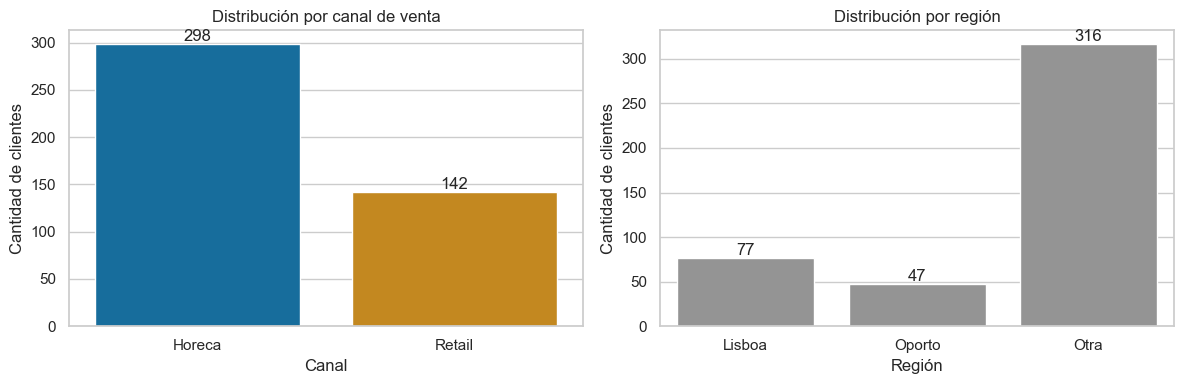

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

orden_canal = ["Horeca", "Retail"]
orden_region = ["Lisboa", "Oporto", "Otra"]

sns.countplot(data=df, x="Canal", order=orden_canal, hue="Canal",
              palette=COLOR_CANAL, legend=False, ax=ejes[0])
ejes[0].set_title("Distribución por canal de venta")

sns.countplot(data=df, x="Región", order=orden_region, color=PALETA[7], ax=ejes[1])
ejes[1].set_title("Distribución por región")

for eje in ejes:
    eje.set_ylabel("Cantidad de clientes")
    for contenedor in eje.containers:
        eje.bar_label(contenedor)

fig.tight_layout()
guardar_figura(fig, "eda_categoricas")
plt.show()

**Interpretación.** La muestra está desbalanceada en ambas variables: el canal Horeca concentra el 67,7 % de los clientes (298) frente al 32,3 % de Retail (142), y el 71,8 % de las observaciones (316) proviene de regiones distintas de Lisboa y Oporto. La tabla de contingencia muestra que la composición por canal es relativamente similar entre regiones (la proporción de Retail varía entre el 23 % en Lisboa y el 40 % en Oporto), por lo que no se aprecia una interacción fuerte entre ambas variables. Dado el desbalance y la escasa granularidad de `Region`, se anticipa que el canal será la pseudo-etiqueta más informativa para la validación externa.

### 3.3 Estadísticas descriptivas de las variables de gasto

Se calculan las estadísticas descriptivas de las seis variables de gasto: medidas de posición (media, mediana, cuartiles), de dispersión (desvío estándar, mínimo y máximo) y de forma. Estas últimas son especialmente relevantes para lo que sigue: la **asimetría** (*skewness*, igual a 0 en una distribución simétrica) y la **curtosis en exceso** (igual a 0 en una distribución normal) permiten cuantificar el alejamiento de la normalidad, condición que afecta tanto a los algoritmos basados en distancias euclídeas como a los modelos de mezclas gaussianas.

In [7]:
descriptivos = df[VARS_GASTO].describe().T
descriptivos["asimetría"] = df[VARS_GASTO].skew()
descriptivos["curtosis"] = df[VARS_GASTO].kurtosis()
descriptivos.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetría,curtosis
Fresh,440.0,12000.30,12647.33,3.0,3127.75,8504.0,16933.75,112151.0,2.56,11.54
Milk,440.0,5796.27,7380.38,55.0,1533.00,3627.0,7190.25,73498.0,4.05,24.67
Grocery,440.0,7951.28,9503.16,3.0,2153.00,4755.5,10655.75,92780.0,3.59,20.91
Frozen,440.0,3071.93,4854.67,25.0,742.25,1526.0,3554.25,60869.0,5.91,54.69
Detergents_Paper,440.0,2881.49,4767.85,3.0,256.75,816.5,3922.00,40827.0,3.63,19.01
Delicassen,440.0,1524.87,2820.11,3.0,408.25,965.5,1820.25,47943.0,11.15,170.69


**Interpretación.** Las seis variables presentan una **asimetría positiva severa**: en todas ellas la media supera ampliamente a la mediana (por ejemplo, `Fresh`: media 12 000 u.m. frente a mediana 8 504 u.m.) y en cuatro de las seis el desvío estándar supera a la media, lo que indica una dispersión extrema. Los coeficientes de asimetría oscilan entre 2,56 (`Fresh`) y 11,15 (`Delicassen`), y la curtosis alcanza valores de hasta 170,7 (`Delicassen`), evidencia de colas derechas muy pesadas: una minoría de clientes de gran volumen convive con una mayoría de clientes de gasto moderado.

Este comportamiento es típico de variables monetarias y tiene dos consecuencias metodológicas directas: (i) las distancias euclídeas quedarían dominadas por los clientes de mayor gasto si no se transforma la escala, y (ii) el supuesto gaussiano de los modelos de mezclas resultaría poco plausible sobre los datos crudos. Ambas observaciones motivan la transformación logarítmica que se evalúa a continuación.

### 3.4 Distribuciones: escala original y escala logarítmica

Se representan los histogramas con estimación de densidad (KDE) de las seis variables de gasto, primero en su escala original y luego tras aplicar la transformación `log1p` (logaritmo natural de 1 + x). Se utiliza `log1p` en lugar del logaritmo directo por robustez: aunque en este dataset todos los valores son estrictamente positivos, `log1p` está definida en cero y su efecto sobre valores grandes es indistinguible del logaritmo simple. La comparación visual de ambas escalas permite evaluar si la transformación corrige la asimetría detectada en la sección anterior.

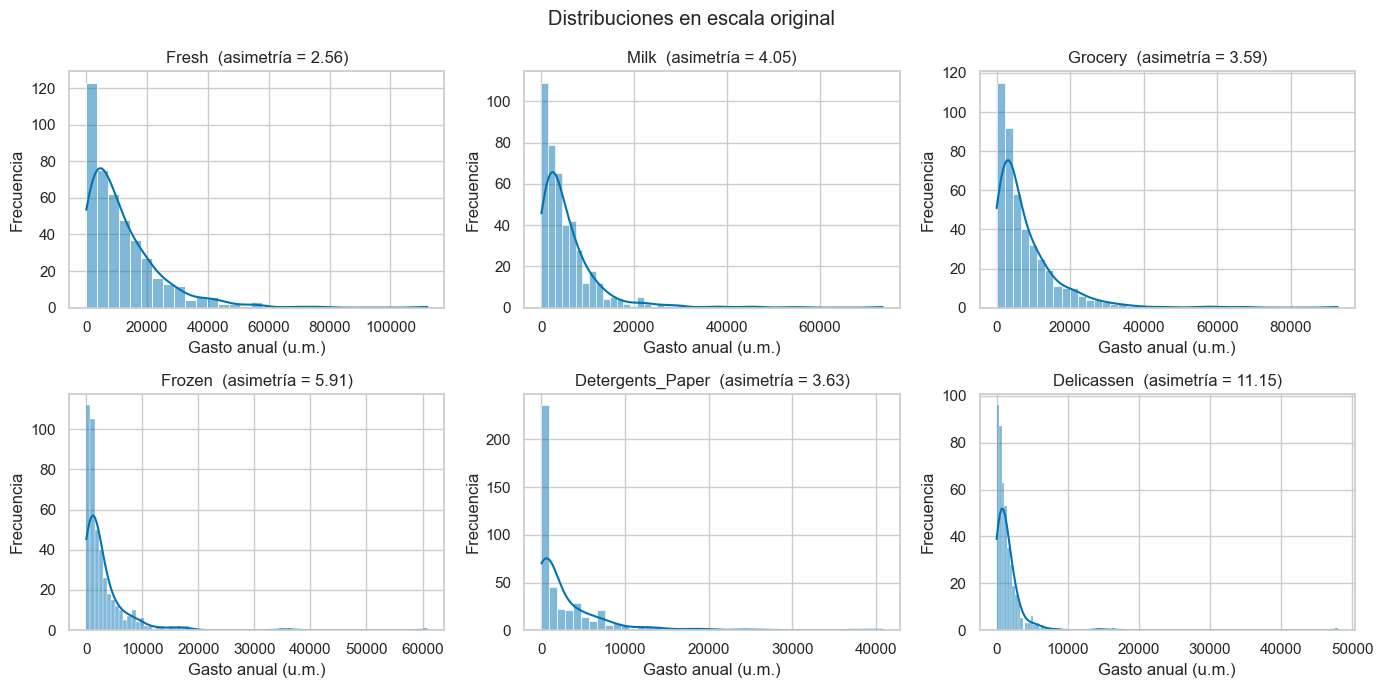

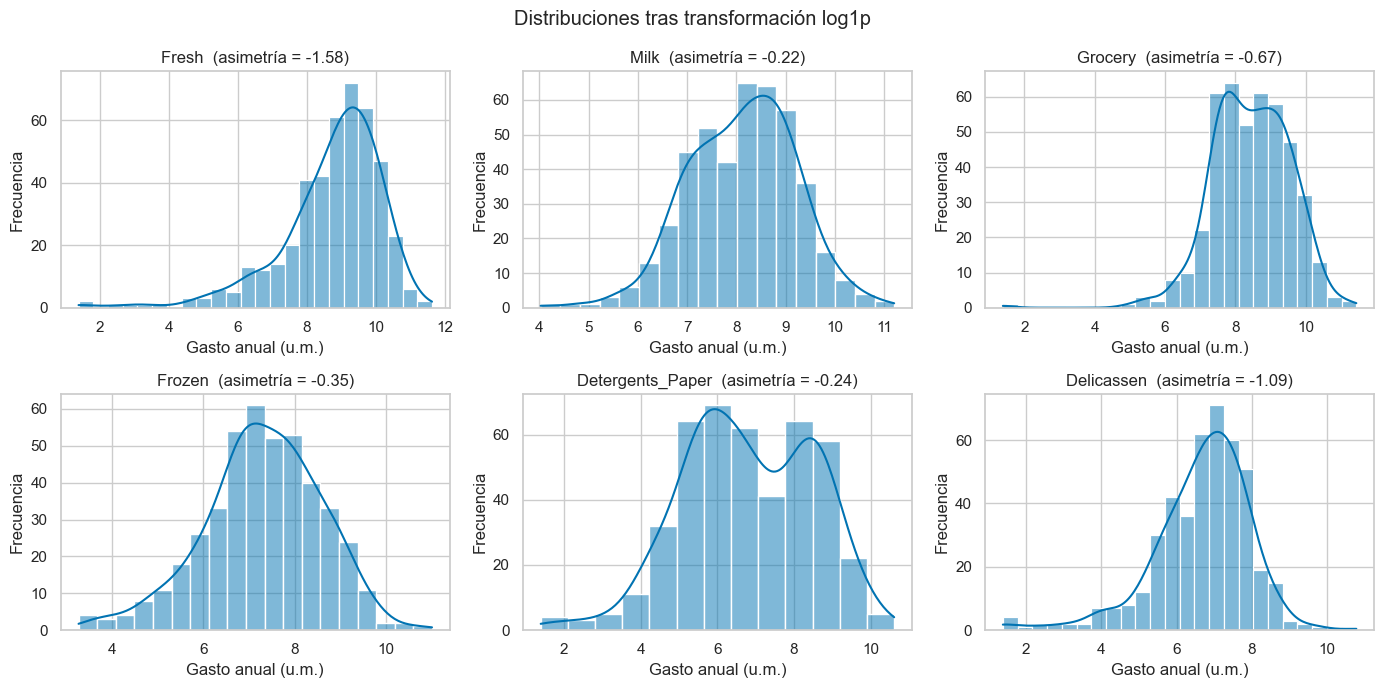

In [8]:
def graficar_distribuciones(datos, titulo, nombre_archivo):
    fig, ejes = plt.subplots(2, 3, figsize=(14, 7))
    for eje, col in zip(ejes.ravel(), VARS_GASTO):
        sns.histplot(datos[col], kde=True, color=PALETA[0], ax=eje)
        eje.set_title(f"{col}  (asimetría = {datos[col].skew():.2f})")
        eje.set_xlabel("Gasto anual (u.m.)")
        eje.set_ylabel("Frecuencia")
    fig.suptitle(titulo)
    fig.tight_layout()
    guardar_figura(fig, nombre_archivo)
    plt.show()


graficar_distribuciones(df[VARS_GASTO], "Distribuciones en escala original",
                        "eda_distribuciones_original")
graficar_distribuciones(np.log1p(df[VARS_GASTO]),
                        "Distribuciones tras transformación log1p",
                        "eda_distribuciones_log")

**Interpretación.** En escala original las seis distribuciones concentran la masa cerca del origen con colas derechas muy largas, coherente con los coeficientes de asimetría calculados. Tras la transformación logarítmica, las distribuciones se vuelven aproximadamente unimodales y mucho más simétricas: la asimetría residual se reduce a valores entre −1,58 (`Fresh`) y −0,22 (`Milk`). La leve asimetría negativa remanente en `Fresh` y `Delicassen` se explica por los clientes con gasto casi nulo detectados en 3.1, cuyo logaritmo produce valores aislados en el extremo inferior.

La evidencia respalda adoptar la transformación logarítmica en el preprocesamiento: acerca los datos a las condiciones de aplicabilidad de los algoritmos basados en distancias y del modelo de mezclas gaussianas.

### 3.5 Correlaciones entre variables de gasto

Se calculan dos matrices de correlación complementarias: **Pearson**, que mide asociación lineal pero es sensible a valores extremos, y **Spearman**, basada en rangos y por tanto robusta frente a los outliers y a la asimetría documentadas en las secciones previas. La coincidencia de ambas matrices indicaría que las asociaciones observadas reflejan la estructura general de los datos y no el efecto de unos pocos clientes extremos. Se emplea una escala de color divergente centrada en cero, de modo que el tono codifica el signo de la correlación y la intensidad su magnitud.

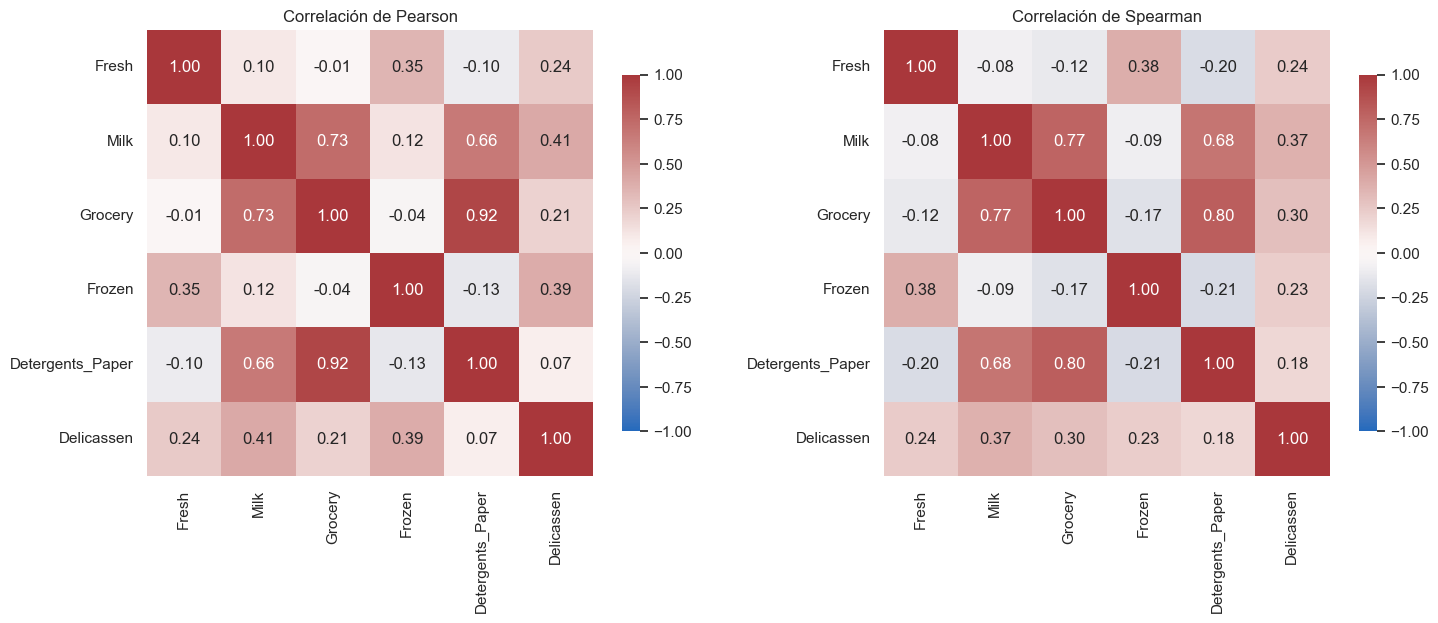

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

for eje, metodo in zip(ejes, ["pearson", "spearman"]):
    matriz = df[VARS_GASTO].corr(method=metodo)
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="vlag", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=eje)
    eje.set_title(f"Correlación de {metodo.capitalize()}")

fig.tight_layout()
guardar_figura(fig, "eda_correlaciones")
plt.show()

**Interpretación.** Ambas matrices coinciden en lo esencial, lo que descarta que las asociaciones sean un artefacto de los valores extremos. Se identifica un **bloque fuertemente correlacionado** formado por `Grocery`, `Milk` y `Detergents_Paper` (Pearson: 0,93 entre `Grocery` y `Detergents_Paper`; 0,73 entre `Milk` y `Grocery`; Spearman confirma con 0,80 y 0,77 respectivamente), interpretable como una *canasta de reposición minorista*. Un segundo eje, más débil, asocia `Fresh` con `Frozen` (0,35), compatible con el perfil de compra de la hostelería. `Delicassen` muestra correlaciones moderadas y difusas con el resto.

Dos implicaciones para el modelado: (i) la redundancia del bloque `Grocery`–`Milk`–`Detergents_Paper` sugiere que la dimensionalidad efectiva de los datos es menor que las seis variables observadas, lo que da sustento al uso de representaciones latentes (autoencoder en DEC) y de técnicas de reducción de dimensionalidad para visualización; (ii) la existencia de ejes de compra diferenciados anticipa una estructura de grupos separable.

### 3.6 Detección de valores atípicos

Se aplica el criterio estándar del **rango intercuartílico (IQR)**: se considera atípico todo valor situado por debajo de Q1 − 1,5·IQR o por encima de Q3 + 1,5·IQR. Los diagramas de caja permiten visualizar la magnitud del fenómeno en cada variable, y la tabla resume la cantidad y proporción de observaciones atípicas por variable, además del total de filas afectadas por al menos un valor atípico — cifra determinante para decidir el tratamiento.

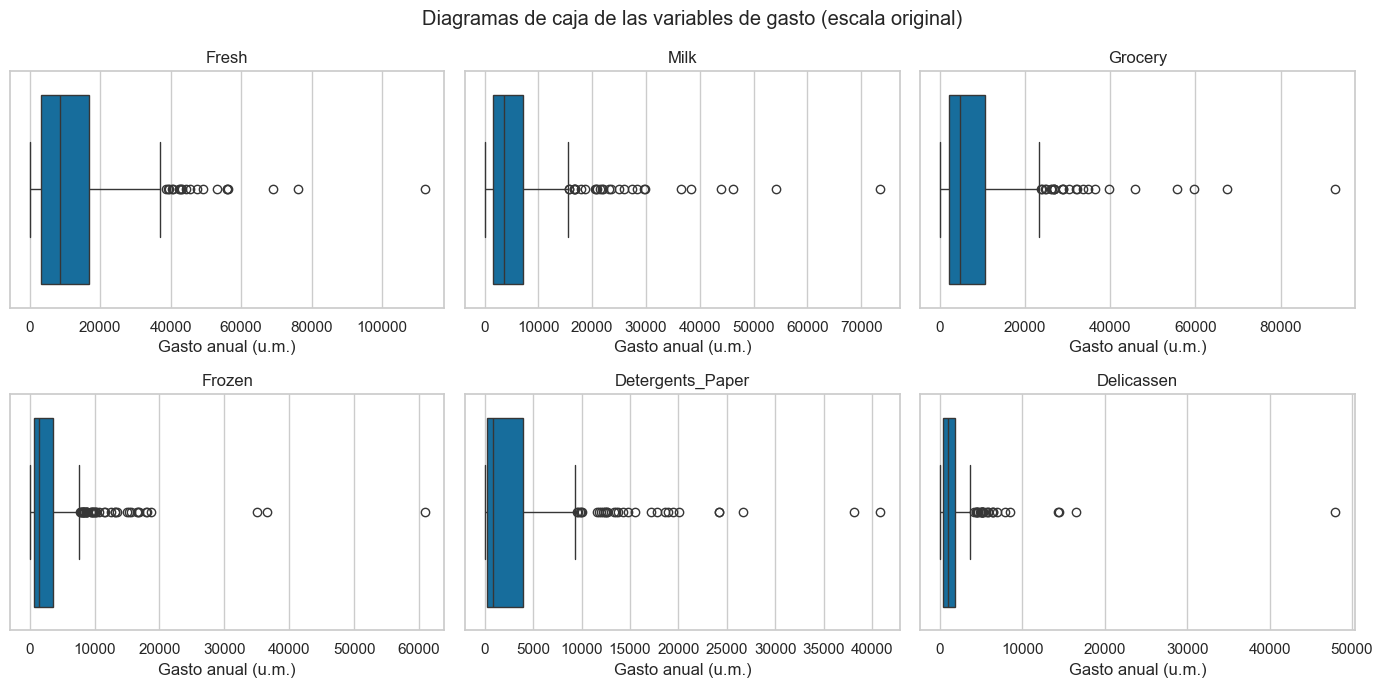

Filas con al menos un valor atípico: 108 de 440 (24.5 %)


,outliers,proporción
Fresh,20.0,0.045
Milk,28.0,0.064
Grocery,24.0,0.055
Frozen,43.0,0.098
Detergents_Paper,30.0,0.068
Delicassen,27.0,0.061


In [10]:
fig, ejes = plt.subplots(2, 3, figsize=(14, 7))
for eje, col in zip(ejes.ravel(), VARS_GASTO):
    sns.boxplot(x=df[col], color=PALETA[0], ax=eje)
    eje.set_title(col)
    eje.set_xlabel("Gasto anual (u.m.)")
fig.suptitle("Diagramas de caja de las variables de gasto (escala original)")
fig.tight_layout()
guardar_figura(fig, "eda_boxplots")
plt.show()


def resumen_outliers_iqr(datos):
    filas = {}
    fuera_alguna = pd.Series(False, index=datos.index)
    for col in datos.columns:
        q1, q3 = datos[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        fuera = (datos[col] < q1 - 1.5 * iqr) | (datos[col] > q3 + 1.5 * iqr)
        fuera_alguna |= fuera
        filas[col] = {"outliers": int(fuera.sum()),
                      "proporción": round(float(fuera.mean()), 3)}
    resumen = pd.DataFrame(filas).T
    total = int(fuera_alguna.sum())
    print(f"Filas con al menos un valor atípico: {total} de {len(datos)} "
          f"({100 * total / len(datos):.1f} %)")
    return resumen


resumen_outliers_iqr(df[VARS_GASTO])

**Interpretación y decisión de tratamiento.** Cada variable presenta entre un 4,5 % (`Fresh`) y un 9,8 % (`Frozen`) de valores atípicos, pero el dato decisivo es agregado: **108 filas (el 24,5 % de la muestra) contienen al menos un valor atípico**. Eliminar estas observaciones supondría descartar una cuarta parte de un dataset ya reducido (440 observaciones) y, más importante, los valores extremos no son errores de medición sino **clientes de gran volumen reales** — precisamente un segmento de alto interés comercial que el agrupamiento debería poder caracterizar, no ignorar.

En consecuencia, se decide **conservar todas las observaciones** y mitigar la influencia de los valores extremos mediante la transformación logarítmica justificada en 3.4, que comprime las colas de forma monótona sin descartar información. La sensibilidad de cada algoritmo a los valores extremos remanentes se discutirá al comparar los resultados.

### 3.7 Perfil de gasto según canal de venta

Dado que `Channel` se reserva como pseudo-etiqueta para la validación externa, interesa verificar de antemano si los perfiles de gasto difieren entre canales: de ser así, cabría esperar que los algoritmos de agrupamiento recuperen, al menos parcialmente, esa partición. Se comparan las distribuciones de las seis categorías de gasto entre Horeca y Retail mediante diagramas de caja sobre **escala logarítmica**, que permite comparar variables de magnitudes muy distintas en un mismo eje y atenúa visualmente los extremos ya discutidos.

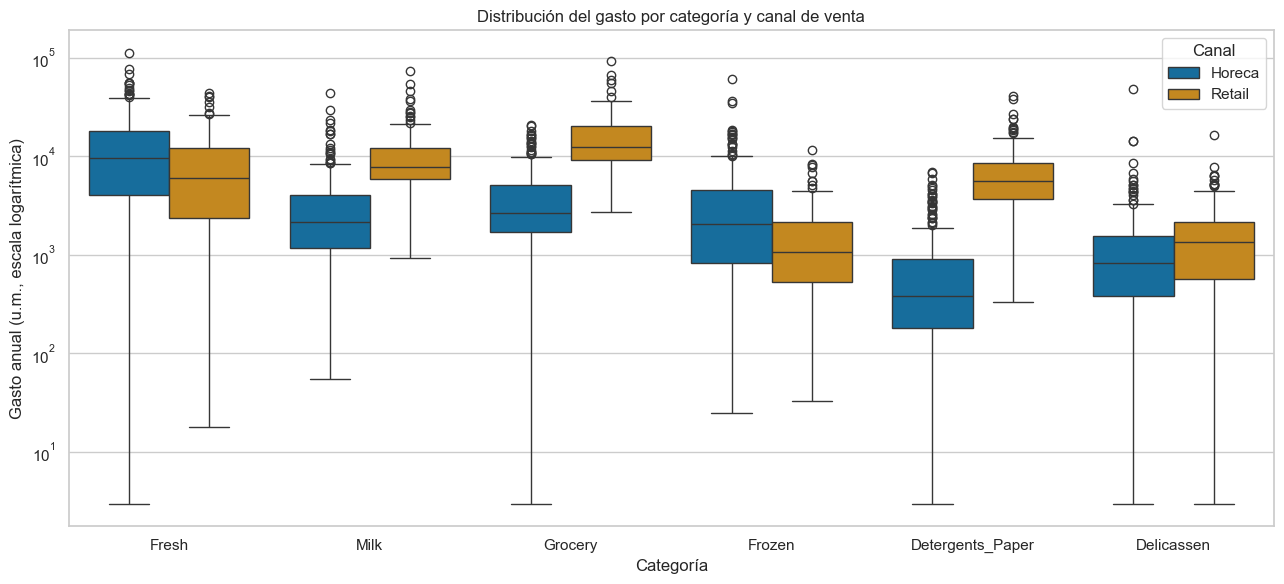

Mediana de gasto anual (u.m.) por canal:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Canal,,,,,,
Horeca,9582.0,2157.0,2684.0,2058.0,386.0,821.0
Retail,5994.0,7812.0,12390.0,1081.0,5614.0,1350.0


In [11]:
gasto_largo = df.melt(id_vars="Canal", value_vars=VARS_GASTO,
                      var_name="Categoría", value_name="Gasto")

fig, eje = plt.subplots(figsize=(13, 6))
sns.boxplot(data=gasto_largo, x="Categoría", y="Gasto", hue="Canal",
            hue_order=["Horeca", "Retail"], palette=COLOR_CANAL, ax=eje)
eje.set_yscale("log")
eje.set_ylabel("Gasto anual (u.m., escala logarítmica)")
eje.set_title("Distribución del gasto por categoría y canal de venta")
fig.tight_layout()
guardar_figura(fig, "eda_gasto_por_canal")
plt.show()

print("Mediana de gasto anual (u.m.) por canal:")
df.groupby("Canal")[VARS_GASTO].median().round(0)

**Interpretación.** Los perfiles de gasto de ambos canales difieren de forma marcada y coherente con el dominio. Los clientes **Retail** gastan sustancialmente más en la canasta de reposición minorista: su mediana en `Grocery` (12 390 u.m.) multiplica por 4,6 la de Horeca (2 684 u.m.), en `Detergents_Paper` (5 615 u.m.) la multiplica por 14,6 (386 u.m.) y en `Milk` por 3,6. Los clientes **Horeca**, en cambio, presentan medianas superiores en `Fresh` (9 582 frente a 5 994 u.m.) y `Frozen` (2 058 frente a 1 081 u.m.), consistente con el consumo de insumos perecederos de la hostelería.

Esta separación, alineada con el bloque de correlaciones identificado en 3.5, permite formular la hipótesis de que la estructura de grupos dominante en los datos estará asociada al canal de venta, con `Detergents_Paper` y `Grocery` como ejes discriminantes principales.

### 3.8 Conclusiones del análisis exploratorio

Las conclusiones del EDA, que condicionan las decisiones metodológicas de las secciones siguientes, se resumen a continuación:

1. **Calidad:** el dataset está completo (sin nulos ni duplicados) y no requiere imputación; las 440 observaciones son utilizables.
2. **Escala y forma:** las seis variables de gasto presentan asimetría positiva severa (coeficientes entre 2,6 y 11,2) y colas pesadas; la transformación logarítmica corrige sustancialmente este comportamiento y se adopta en el preprocesamiento, seguida de un escalado que homogeneice varianzas antes de aplicar algoritmos basados en distancias.
3. **Estructura de correlación:** existe un bloque fuertemente correlacionado (`Grocery`–`Milk`–`Detergents_Paper`) y un eje secundario (`Fresh`–`Frozen`), lo que sugiere una dimensionalidad efectiva menor que 6 y anticipa estructura de grupos separable.
4. **Valores atípicos:** el 24,5 % de las filas contiene al menos un valor atípico según el criterio IQR; se conservan todas las observaciones por tratarse de clientes reales de gran volumen, mitigando su influencia mediante la transformación logarítmica.
5. **Hipótesis de trabajo:** los perfiles de gasto difieren claramente entre canales (Horeca orientado a frescos y congelados; Retail a almacén, lácteos y detergentes), por lo que se espera que la estructura de grupos recuperada guarde relación con `Channel`, variable que se empleará como pseudo-etiqueta en la evaluación externa. Un rango inicial razonable para el número de grupos es k ∈ {2, …, 6}, a validar con criterios internos en cada algoritmo.
6. **Variables de agrupamiento:** el clustering se realizará exclusivamente sobre las seis variables de gasto; `Channel` y `Region` quedan excluidas del espacio de atributos y reservadas para validación externa e interpretación.

## 4. Preprocesamiento

Las decisiones de preprocesamiento se derivan directamente de las conclusiones del EDA (sección 3.8). En síntesis: (i) **no se requiere imputación**, dado que el dataset no presenta valores nulos (3.1); (ii) **no se requiere codificación de variables categóricas**, dado que `Channel` y `Region` quedan excluidas del espacio de atributos; (iii) se aplica una **transformación logarítmica** para corregir la asimetría severa (3.4) y mitigar la influencia de los valores atípicos conservados (3.6); y (iv) se aplica un **escalado** que homogeneice las varianzas antes de utilizar algoritmos basados en distancias. El pipeline resultante es: selección de variables → `log1p` → estandarización.

### 4.1 Selección de variables

El agrupamiento se realiza exclusivamente sobre las seis variables de gasto. La exclusión de `Channel` y `Region` responde a dos razones metodológicas: primero, el objetivo del trabajo es descubrir la estructura de grupos **sin supervisión**, a partir del comportamiento de compra observado; segundo, `Channel` se emplea en la sección 9 como pseudo-etiqueta para la evaluación externa, e incluirla como atributo introduciría circularidad en dicha validación (los clusters reproducirían trivialmente la variable con la que luego se los evalúa).

En la celda siguiente se construye la matriz de atributos cruda (`X_crudo`, de dimensión 440 × 6) y se reservan las etiquetas de canal y región en vectores separados, que se utilizarán únicamente para evaluación e interpretación.

In [12]:
X_crudo = df[VARS_GASTO].copy()
y_canal = df["Canal"].to_numpy()
y_region = df["Región"].to_numpy()

print(f"Matriz de atributos: {X_crudo.shape[0]} observaciones × {X_crudo.shape[1]} variables")
X_crudo.head()

Matriz de atributos: 440 observaciones × 6 variables


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


### 4.2 Transformación logarítmica

Se aplica `log1p` (logaritmo natural de 1 + x) a las seis variables de gasto, conforme a la justificación desarrollada en 3.4: la transformación es monótona (preserva el orden relativo de los clientes), comprime las colas derechas pesadas y acerca las distribuciones a la simetría, condición favorable tanto para las distancias euclídeas como para el supuesto gaussiano de los modelos de mezclas.

La celda siguiente aplica la transformación y verifica su efecto comparando los coeficientes de asimetría antes y después, junto con la cantidad de valores atípicos (criterio IQR) remanentes por variable.

In [13]:
X_log = np.log1p(X_crudo)

verificacion = pd.DataFrame({
    "asimetría original": X_crudo.skew(),
    "asimetría tras log1p": X_log.skew(),
})
for col in VARS_GASTO:
    q1, q3 = X_log[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = (X_log[col] < q1 - 1.5 * iqr) | (X_log[col] > q3 + 1.5 * iqr)
    verificacion.loc[col, "outliers IQR tras log1p"] = int(fuera.sum())

verificacion.round(2)

,asimetría original,asimetría tras log1p,outliers IQR tras log1p
Fresh,2.56,-1.58,16.0
Milk,4.05,-0.22,4.0
Grocery,3.59,-0.67,2.0
Frozen,5.91,-0.35,10.0
Detergents_Paper,3.63,-0.24,2.0
Delicassen,11.15,-1.09,14.0


**Verificación.** La asimetría se reduce de valores entre 2,56 y 11,15 a valores residuales entre −1,58 y −0,22, y las filas afectadas por valores atípicos caen del 24,5 % al 9,5 %. Los atípicos remanentes se concentran en la **cola inferior** (los clientes con gasto casi nulo identificados en 3.1, cuyo logaritmo produce valores aislados en el extremo inferior), un fenómeno mucho menos distorsivo para el agrupamiento que las colas superiores originales, donde un único cliente podía distar órdenes de magnitud del resto.

### 4.3 Estandarización

Aun tras la transformación logarítmica, las variables presentan medias distintas (entre 6,67 y 8,73 en escala log) y varianzas heterogéneas. Sin un escalado posterior, las variables de mayor varianza dominarían las distancias euclídeas empleadas por Agglomerative Clustering (en particular con enlace de Ward), condicionarían las covarianzas estimadas por el modelo de mezclas y dificultarían el entrenamiento por gradiente del autoencoder de DEC. Se comparan tres alternativas habituales:

- **`StandardScaler`** (media 0, desvío 1): apropiado cuando las distribuciones son aproximadamente simétricas, condición que la transformación logarítmica ya garantiza.
- **`RobustScaler`** (mediana y rango intercuartílico): preferible cuando persisten valores atípicos severos que distorsionarían la media y el desvío; tras `log1p` los atípicos remanentes son pocos (9,5 % de las filas) y moderados, por lo que su ventaja se diluye.
- **`MinMaxScaler`** (rango [0, 1]): sensible a los valores extremos, que definen los límites del rango; se descarta por los atípicos remanentes en la cola inferior.

Se adopta en consecuencia **`StandardScaler` sobre los datos transformados**, la combinación estándar en la literatura para variables monetarias. La celda siguiente ajusta el escalador y verifica el resultado (media ≈ 0 y desvío ≈ 1 en todas las variables).

In [14]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_esc = pd.DataFrame(escalador.fit_transform(X_log),
                     columns=VARS_GASTO, index=X_log.index)

X_esc.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
Fresh,0.0,1.0,-5.00,1.97
Milk,-0.0,1.0,-3.79,2.86
Grocery,-0.0,1.0,-6.36,2.70
Frozen,0.0,1.0,-3.16,2.90
Detergents_Paper,-0.0,1.0,-3.17,2.24
Delicassen,-0.0,1.0,-4.09,3.18


La figura siguiente muestra los diagramas de caja de la matriz final: las seis variables quedan en escalas comparables, con la mayor parte de la masa en el intervalo [−2, 2]. Los valores mínimos alejados (hasta −6,4 desvíos en `Grocery`) corresponden a los clientes de actividad casi nula ya documentados; se conservan por las razones expuestas en 3.6.

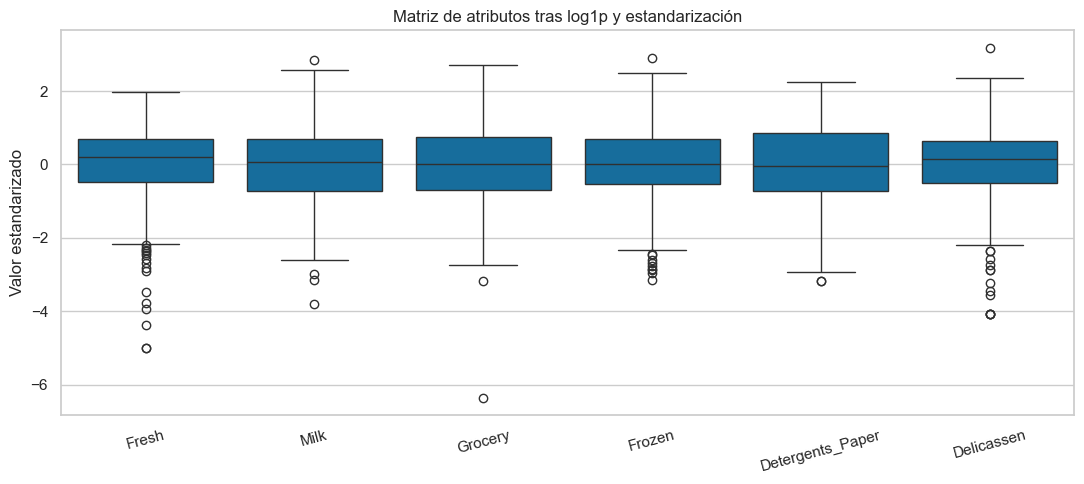

In [15]:
fig, eje = plt.subplots(figsize=(11, 5))
sns.boxplot(data=X_esc, color=PALETA[0], ax=eje)
eje.set_title("Matriz de atributos tras log1p y estandarización")
eje.set_ylabel("Valor estandarizado")
eje.tick_params(axis="x", rotation=15)
fig.tight_layout()
guardar_figura(fig, "prep_matriz_final")
plt.show()

### 4.4 Síntesis del preprocesamiento

El resultado del preprocesamiento es la matriz `X_esc` (440 × 6), obtenida mediante `log1p` seguida de estandarización, sin eliminación de observaciones. **Todos los algoritmos de las secciones 5 a 8 se entrenan sobre esta misma matriz**, lo que garantiza que las diferencias de desempeño observadas en la sección 9 sean atribuibles a los métodos y no a diferencias en la preparación de los datos. Las variables `Channel` y `Region` permanecen fuera del espacio de atributos, reservadas para la evaluación externa y la interpretación de los grupos.

## 5. Baseline de referencia: K-Means

> K-Means se utiliza **únicamente como referencia** (según la consigna no computa como uno de los dos algoritmos requeridos). Sirve para fijar un k inicial y como piso de comparación.

*Pendiente: método del codo y análisis de silhouette para la elección de k.*

## 6. Agglomerative Clustering

*Pendiente: dendrograma, optimización de `n_clusters`, `linkage` y métrica de distancia, con justificación.*

## 7. Gaussian Mixture Models

*Pendiente: optimización de `n_components` y `covariance_type` mediante BIC/AIC; análisis de asignaciones blandas (probabilidades de pertenencia).*

## 8. Deep Embedded Clustering (DEC)

Técnica avanzada de deep clustering (Xie et al., 2016): un autoencoder aprende una representación latente y luego se refinan simultáneamente el embedding y los centroides minimizando la divergencia KL respecto de una distribución objetivo.

*Pendiente: pre-entrenamiento del autoencoder, fase de refinamiento y justificación de la arquitectura para un dataset de 440 observaciones.*

## 9. Evaluación y comparación de métodos

*Pendiente: tabla comparativa con métricas internas (Silhouette, Davies-Bouldin, Calinski-Harabasz) y externas respecto de `Channel` (ARI, NMI). Interpretación crítica.*

## 10. Visualización con t-SNE

*Pendiente: proyección 2D coloreada por cada algoritmo y por `Channel`/`Region`; discusión del hiperparámetro perplexity y de las limitaciones del método; perfilado de clusters.*

## 11. Discusión y conclusiones

*Pendiente: comparación crítica de los métodos, interpretación de negocio de la segmentación, limitaciones (tamaño muestral para DEC, sensibilidad a valores extremos) y líneas de trabajo futuro.*

## 12. Referencias

- Cardoso, M. (2013). *Wholesale customers* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5030X
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- van der Maaten, L., & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9(86), 2579–2605.
- Wong, B. (2011). Points of view: Color blindness. *Nature Methods*, 8(6), 441.
- Xie, J., Girshick, R., & Farhadi, A. (2016). Unsupervised Deep Embedding for Clustering Analysis. *Proceedings of the 33rd International Conference on Machine Learning* (ICML).